# Proyecto Simulación Montecarlo Nvidia, AMD, Intel e IBM

## Introducción

En este trabajo de simulación matemática analizaremos los activos de Nvidia, AMD, Intel e IBM para realizar un análisis sobre el comportamiento en el precio de los activos para el perdiodo 2020 y poder comparar los resultados obtenidos con los reales 2021, así mismo observar si los activos pudieron sobrepasar un  precio umbral del 10%.


## Objetivos

- Utilizar la simulación montecarlo para analizar los precios de los activos de Nvidia, AMD, Intel e IBM.


- Calcular los rendimientos de los activos puestos a estudio.
- Realizar las gráficas correspondientes para poder visualizar los resultados de manera precisa.
- Analizar los activos para poder observar si estos mismos sobrepasan el precio umbral.

## Modelo

Realizaremos una simulación sobre el precio de los activos para ver cómo se comporta durante el periodo 2020 para ello realizaremos las siguientes actividades.


+ Descargar los datos desde Yahoo Finance y utilizaremos las herramientas de Panda DataReader
+ Crearemos una función para descargar los precios ajustados al cierre de los 4 activos que manejaremos
+ Simularemos los rendimientos de los activos
+ Calcularemos las medias y desviaciones estándar de cada uno de los activos
+ Simularemos los escenarios para cada uno de los activos
+ Proyectaremos los precios al cierre de cada uno de los activos
+ Calcularemos la probabilidad Precio-Umbral
+ Y por último compararemos los datos reales con el valor Precio-Umbral para ver si lo llegó a respetar


In [1]:
# Importamos librerías
import yfinance as yf
import pandas as pd
import pandas_datareader as web
import matplotlib.pyplot as plt
from matplotlib.lines import lineStyles
import numpy as np

In [2]:
# Instrumento:

accion=['NVDA','AMD','INTC','IBM']

# Fechas de inicio y fin a descargar:

start='2016-01-01'
end='2020-12-31'

# Obtenemos los datos
datos = yf.download(accion, start=start, end=end, auto_adjust=True)
precios = datos["Close"]

[*********************100%***********************]  4 of 4 completed


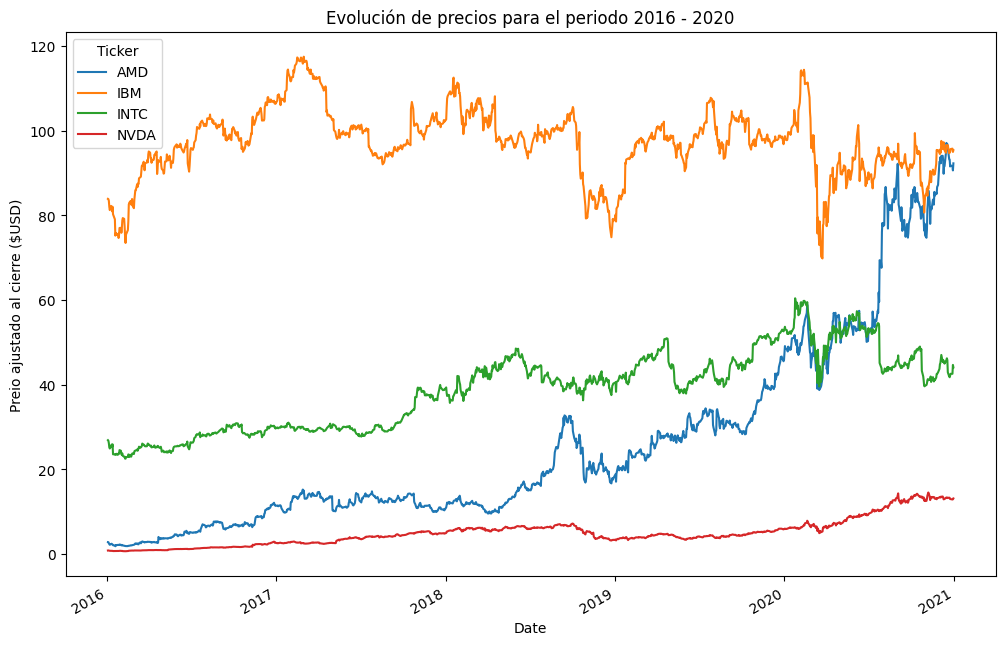

In [3]:
# Graficamos

precios.plot(title="Evolución de precios para el periodo 2016 - 2020",
             figsize=(12,8))

plt.ylabel("Preio ajustado al cierre ($USD)")
plt.show()

In [4]:
# Calcular rendimientos diarios y graficarlos

rendimientos = np.log(precios/precios.shift(1))
rendimientos

Ticker,AMD,IBM,INTC,NVDA
Date,,,,
2016-01-04,NaN,NaN,NaN,NaN
2016-01-05,-0.007246,-0.000736,-0.004719,0.015937
2016-01-06,-0.091318,-0.005018,-0.022419,-0.042230
2016-01-07,-0.096107,-0.017238,-0.038205,-0.040452
2016-01-08,-0.063370,-0.009301,-0.010418,-0.021700
...,...,...,...,...
2020-12-23,-0.017433,0.002343,0.008626,-0.020467
2020-12-24,0.002836,0.006356,0.010679,-0.001192
2020-12-28,-0.002290,0.001042,0.000000,-0.007241


In [5]:
# Obtenemos el rendimiento y la desviación estandar
# para la serie de tiempo obtenida

acciones = ['NVDA','AMD','INTC','IBM']

df_rendimientos = pd.DataFrame(
    {
        "Media":rendimientos.mean(),
        "Desviación estándar":rendimientos.std()
    },
    index=acciones

    )

df_rendimientos.style\
  .format("{:.6f}")\
  .set_properties(**{'text-align': 'center'})\
  .set_table_styles([
      {'selector': 'th',
       'props': [('text-align', 'center')]}
  ])
#


,Media,Desviación estándar
NVDA,0.002235,0.029794
AMD,0.002789,0.040032
INTC,0.000394,0.021091
IBM,0.000102,0.016342


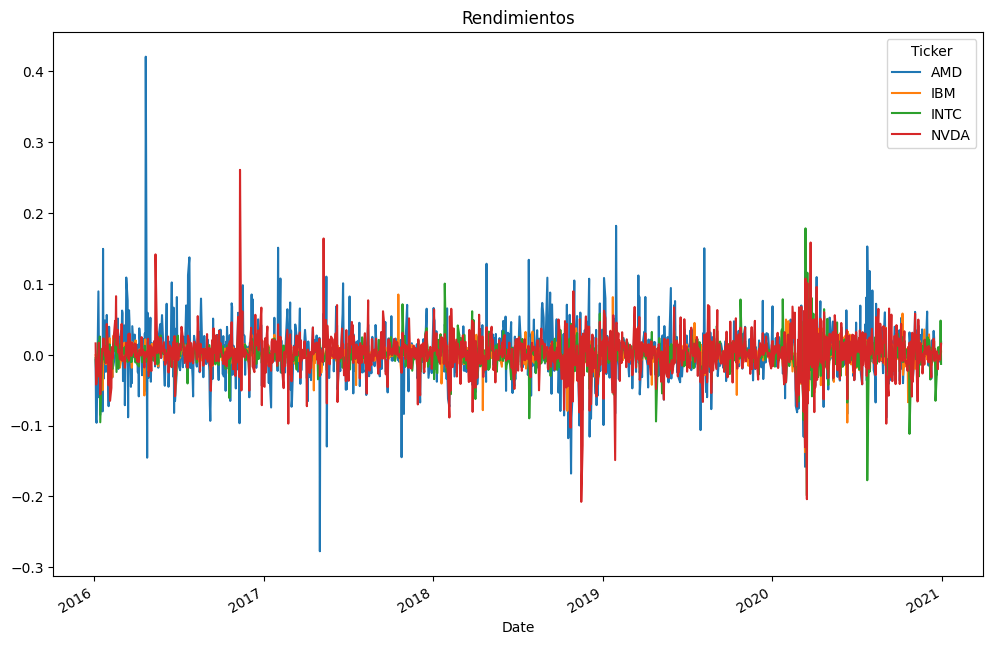

In [6]:
# Calculamos media y desviación estándar

rendimientos.plot(title="Rendimientos",
                  figsize=(12,8))
plt.show()

In [7]:
# Función que simula varios escenarios de rendimientos diarios

def simulacion_rendimientos(mu, sigma, ndays, nscen, start_date):
    fechas=pd.date_range(start=start_date, periods=ndays)
    simulacion=sigma*np.random.randn(ndays, nscen)+(mu-0.5*sigma**2)
    tabla=pd.DataFrame(index=fechas, data=simulacion)
    return tabla

In [8]:
# Diccionario para guardar los resultados de los rendimientos simulados
simulaciones_rend = {}

# Media y volatilidad

media=rendimientos.mean()
sigma=rendimientos.std()

for accion in acciones:

  # Obtenemos media y volatilidad
  mu_accion = media[accion]
  sigma_accion = sigma[accion]

  # Definimos
  ndays=365
  nscen=2500
  start_date='2021-01-01'

  # Simulamos
  resultado_rend = simulacion_rendimientos(
      mu_accion,
      sigma_accion,
      ndays,
      nscen,
      start_date = '2021-01-01',

  )

  simulaciones_rend[accion] = resultado_rend

In [9]:
# Diccionario para guardar los resultados de los precios simulados
precios_simulados = {}

for accion in acciones:
  # Generamos la proyección de los precios
  resultado_prec = precios[accion].iloc[-1]*np.exp(simulaciones_rend[accion]).cumprod()

  # El resultado será guardado en el diccionario
  precios_simulados[accion] = resultado_prec



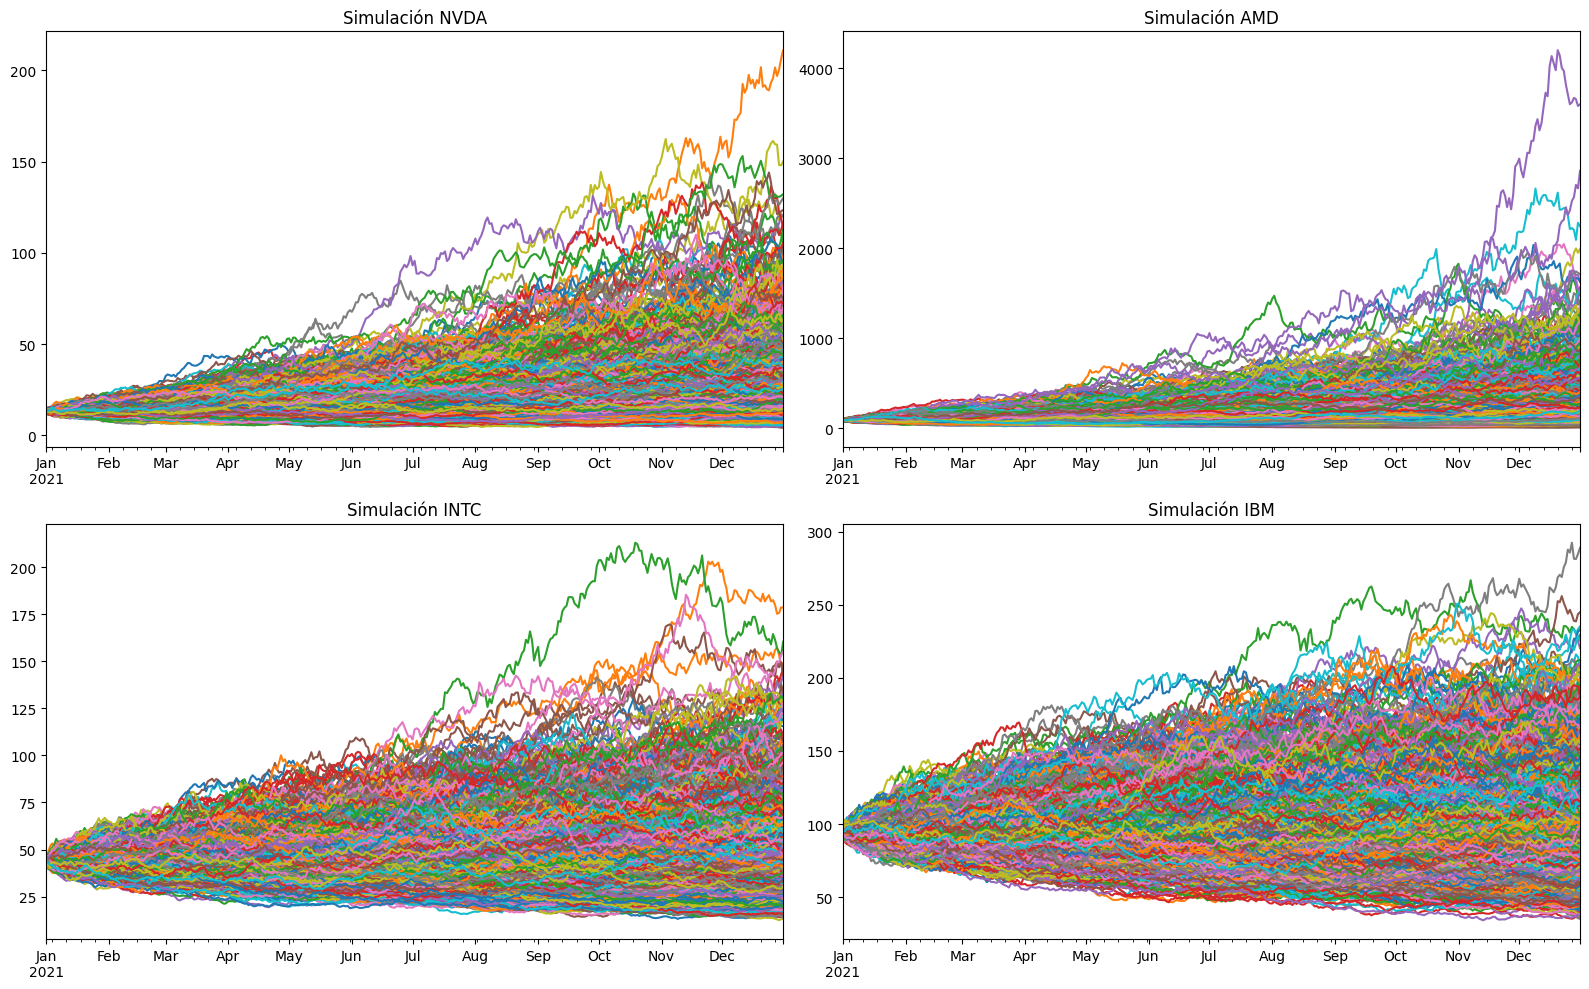

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for i, accion in enumerate(acciones):

    fila = i // 2
    columna = i % 2

    precios_simulados[accion].plot(
        ax=axes[fila, columna],
        title=f"Simulación {accion}",
        legend=False
    )

plt.tight_layout()
plt.show()

In [11]:
# Umbral de 110% del ultimo precio

K1=precios['NVDA'].iloc[-1]*1.1
K2=precios['AMD'].iloc[-1]*1.1
K3=precios['INTC'].iloc[-1]*1.1
K4=precios['IBM'].iloc[-1]*1.1

# Fechas

fechas1=precios_simulados['NVDA'].index
fechas2=precios_simulados['AMD'].index
fechas3=precios_simulados['INTC'].index
fechas4=precios_simulados['IBM'].index

In [12]:
probabilidades = {}

for accion in acciones:

  # Precio umbral (+10%)
  K=precios[accion].iloc[-1]*1.1

  # ¿Cuántos precios simulados son mayor al umbral?
  TF = precios_simulados[accion] > K

  # Sumamos para cada fecha y dividimos entre el número de escenarios

  prob=TF.sum(axis=1)/2500

  # Guardamos los resultados
  probabilidades[accion] = prob

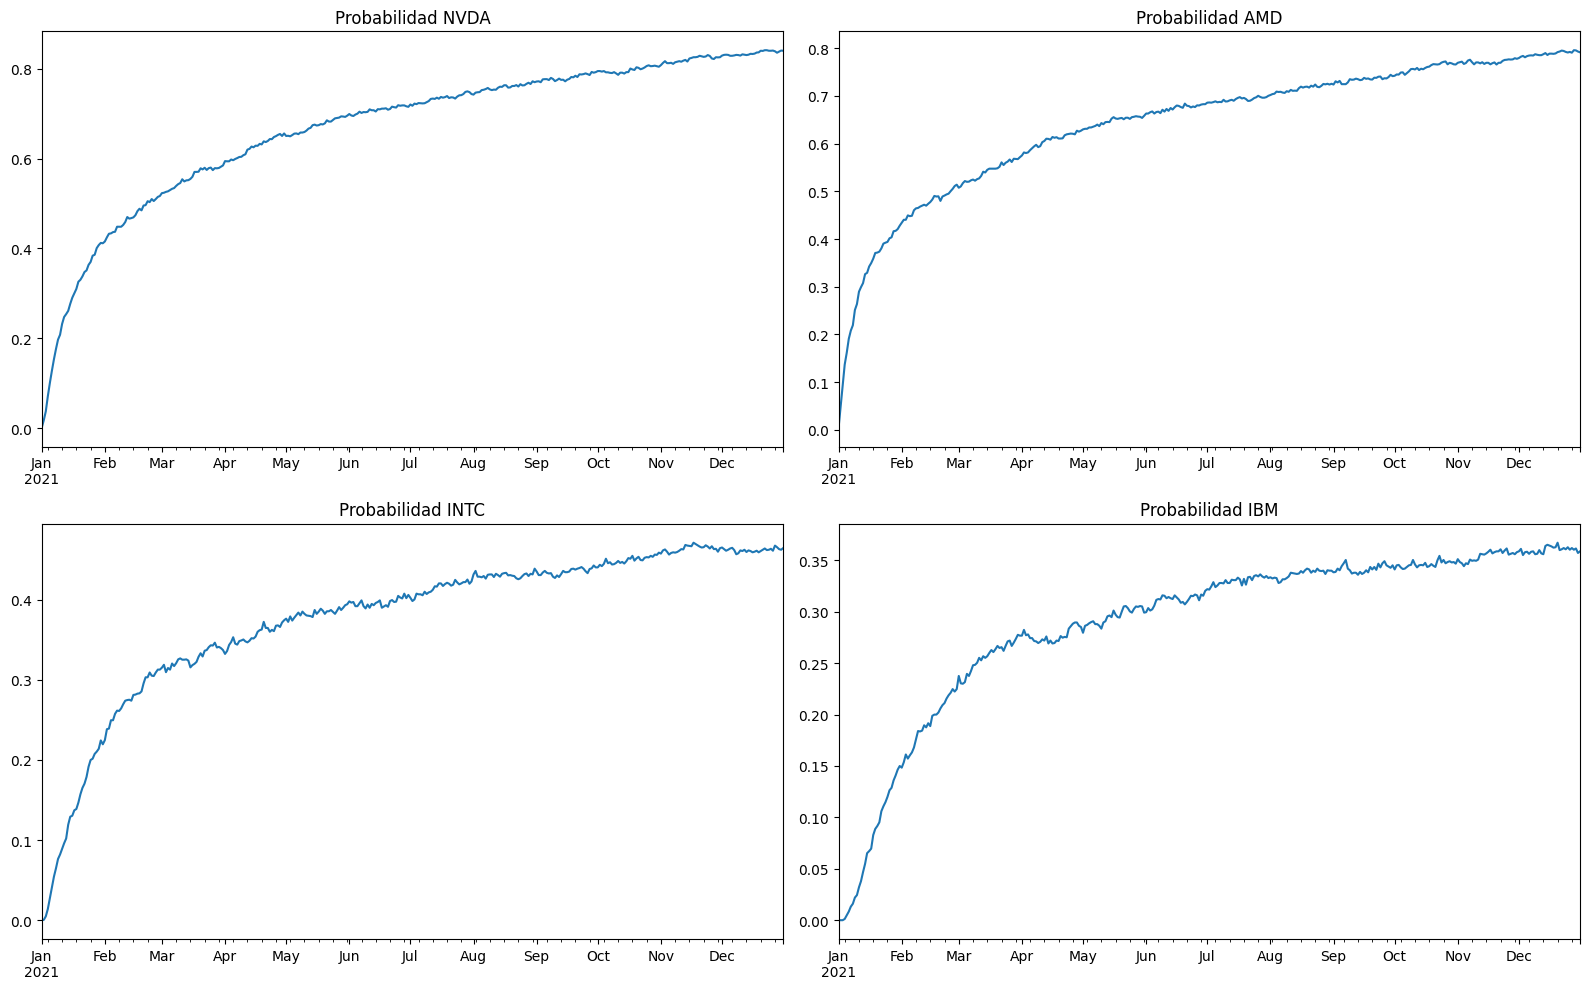

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for i, accion in enumerate(acciones):

    fila = i // 2
    columna = i % 2

    probabilidades[accion].plot(
        ax=axes[fila, columna],
        title=f"Probabilidad {accion}",
        legend=False
    )

plt.tight_layout()
plt.show()

[*********************100%***********************]  1 of 1 completed


<Figure size 1200x800 with 0 Axes>

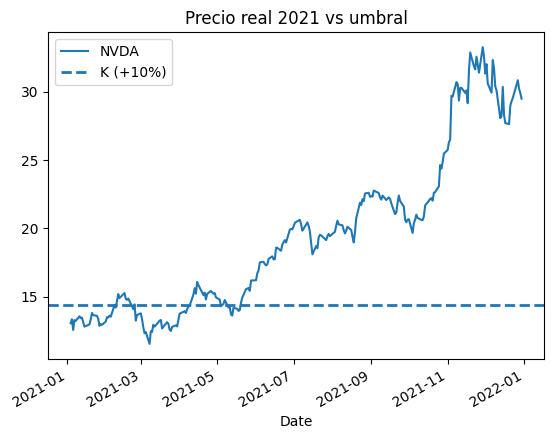

[*********************100%***********************]  1 of 1 completed


<Figure size 1200x800 with 0 Axes>

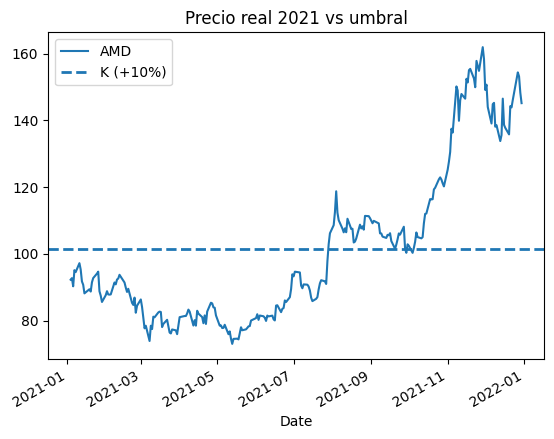

[*********************100%***********************]  1 of 1 completed


<Figure size 1200x800 with 0 Axes>

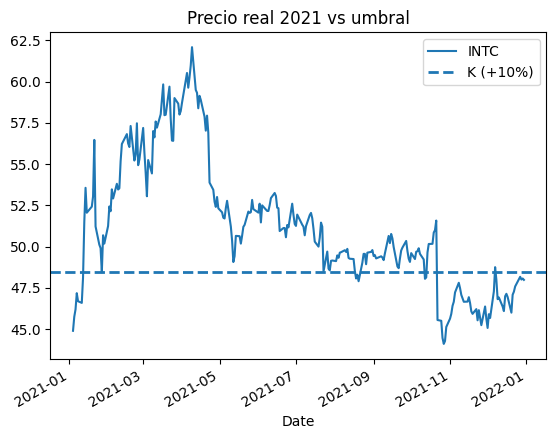

[*********************100%***********************]  1 of 1 completed


<Figure size 1200x800 with 0 Axes>

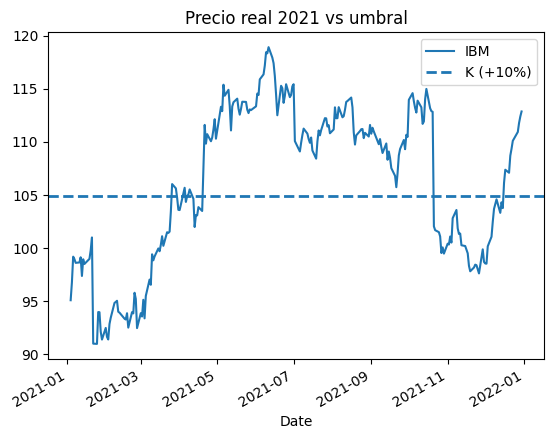

In [14]:

# Definimos las fechas de inicio y fin.
start = '2021-01-01'
end = '2021-12-31'

for accion in acciones:

    # Descargar precios reales

    datos_reales = yf.download(accion, start=start, end=end, auto_adjust=True)
    precios_reales = datos_reales['Close']

    # Calcular K
    K=precios[accion].iloc[-1]*1.1

    # Graficar precio real

    plt.figure(figsize=(12,8))

    precios_reales.plot(
        title=f"Precio real 2021 vs umbral"
    )

    # Dibujar K

    plt.axhline(
        y=K,
        linestyle='--',
        linewidth=2,
        label='K (+10%)',
    )
    plt.legend()
    plt.show()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


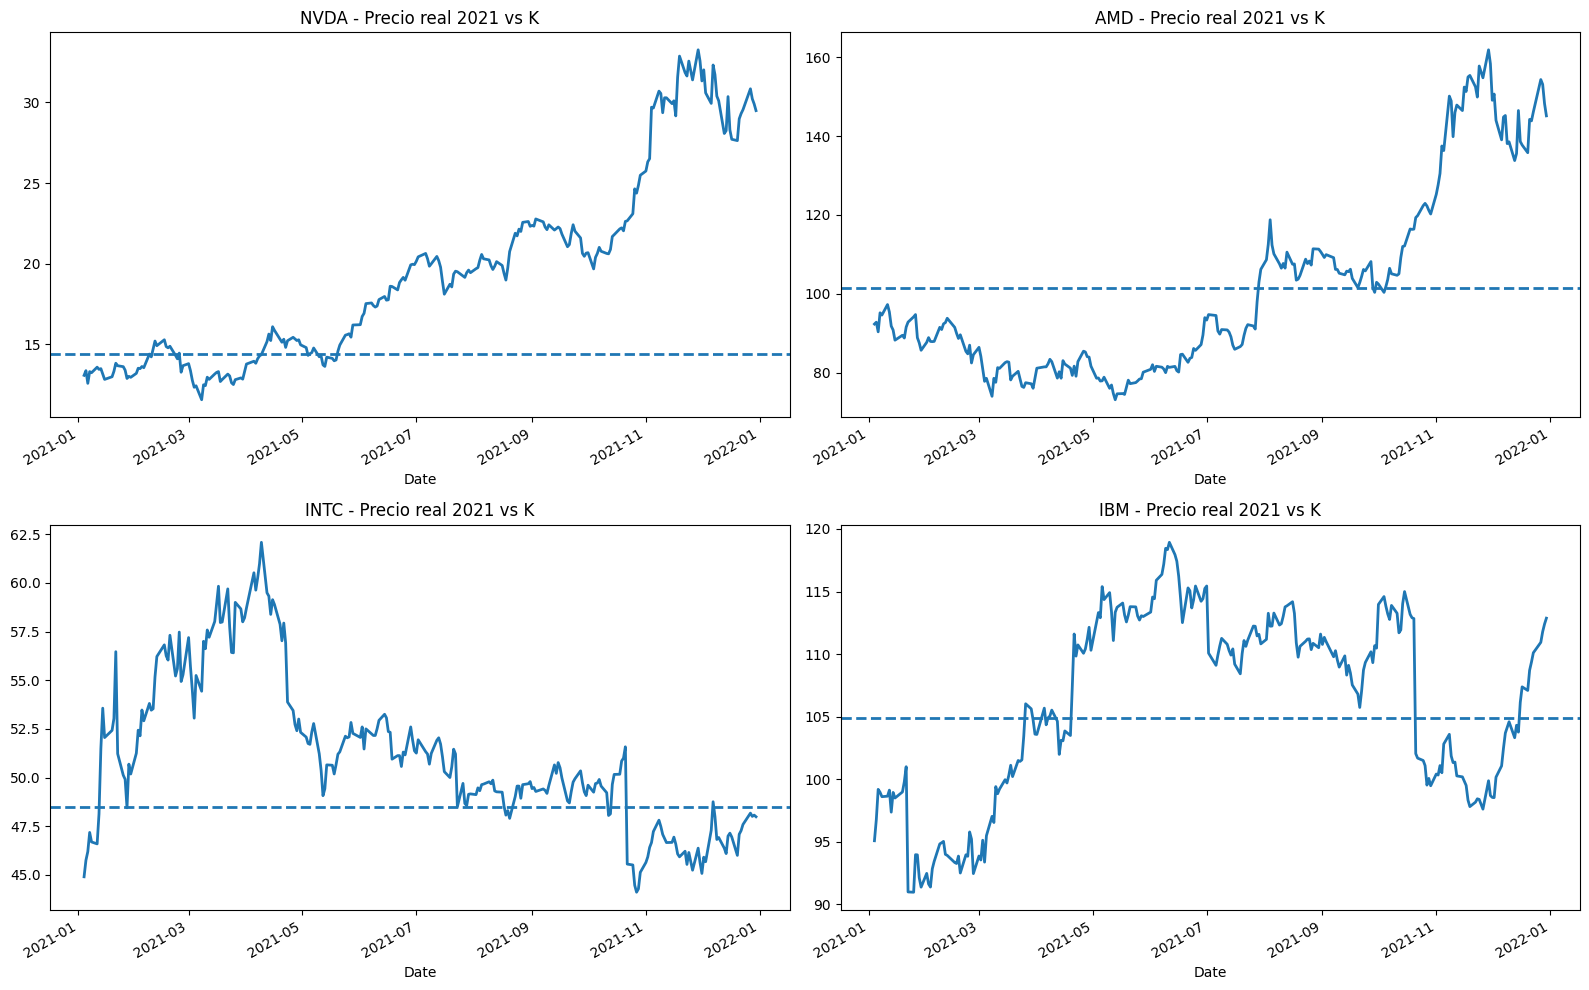

In [15]:
# Definimos las fechas de inicio y fin.
start = '2021-01-01'
end = '2021-12-31'

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for i, accion in enumerate(acciones):

    # Descargar precios reales

    datos_reales = yf.download(accion, start=start, end=end, auto_adjust=True)
    precios_reales = datos_reales['Close']

    # Calcular K
    K=precios[accion].iloc[-1]*1.1

    #Ubicación del gráfico
    fila = i // 2
    columna = i % 2

    # Graficar precio real
    precios_reales.plot(
        ax=axes[fila, columna],
        title=f"{accion} - Precio real 2021 vs K",
        linewidth=2,
        legend=False
    )

    # Dibujar K

    axes[fila, columna].axhline(
        y=K,
        linestyle='--',
        linewidth=2,
        label='K (+10%)'
    )

plt.tight_layout()
plt.show()